In [3]:
import numpy as np 
import matplotlib.pyplot as plt
import Corrfunc

In [4]:
#devo buttare delle particelle a caso in un box
box_size = 1000 #mpc/h
n_points= 50000
volume = box_size**3
density = n_points/volume
print(f"Density of particles: {density:.6f} [mpc/h]^3")

Density of particles: 0.000050 [mpc/h]^3


In [5]:
X,Y,Z= np.random.rand(3,n_points)*box_size
#espandiamo questi punti avro 5000


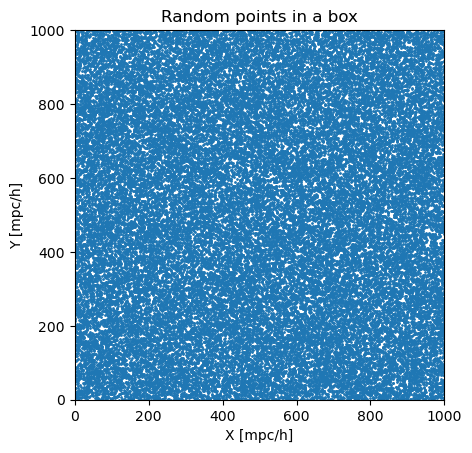

In [6]:
plt.plot(X,Y, 'o', markersize=1)
plt.xlim(0,box_size)
plt.ylim(0,box_size)
plt.xlabel('X [mpc/h]')
plt.ylabel('Y [mpc/h]')
plt.title('Random points in a box')
plt.gca().set_aspect('equal', adjustable='box')
plt.savefig('random_points.png', dpi=300)
plt.show()

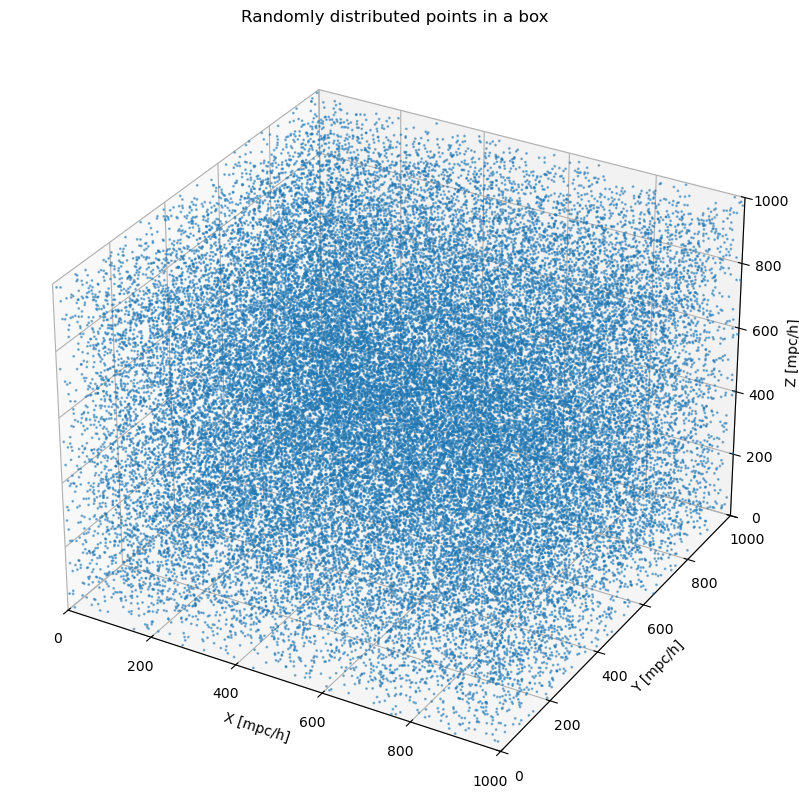

In [7]:
#mi grafico i punti 
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X,Y,Z, s=1, alpha=0.5)
ax.set_xlabel('X [mpc/h]')
ax.set_ylabel('Y [mpc/h]')
ax.set_zlabel('Z [mpc/h]')
ax.set_xlim(0,box_size)
ax.set_ylim(0,box_size)
ax.set_zlim(0,box_size)
plt.title('Randomly distributed points in a box')
plt.show()


In [8]:
r_min= 0
r_max= 20
n_bins= 20
bin_edges= np.linspace(r_min, r_max, n_bins+1)

In [9]:
bin_edges 

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20.])

In [15]:
#compute pairs

RR= Corrfunc.theory.DD(
    autocorr=True,
    nthreads=4,
    binfile=bin_edges,
    X1=X,
    Y1=Y,
    Z1=Z,
    boxsize=box_size,
    periodic=True)

In [11]:
RR

array([( 0.,  1., 0., 50016, 0.), ( 1.,  2., 0.,    72, 0.),
       ( 2.,  3., 0.,   182, 0.), ( 3.,  4., 0.,   386, 0.),
       ( 4.,  5., 0.,   598, 0.), ( 5.,  6., 0.,   940, 0.),
       ( 6.,  7., 0.,  1372, 0.), ( 7.,  8., 0.,  1828, 0.),
       ( 8.,  9., 0.,  2248, 0.), ( 9., 10., 0.,  2790, 0.),
       (10., 11., 0.,  3656, 0.), (11., 12., 0.,  4228, 0.),
       (12., 13., 0.,  4804, 0.), (13., 14., 0.,  5806, 0.),
       (14., 15., 0.,  6514, 0.), (15., 16., 0.,  7712, 0.),
       (16., 17., 0.,  8838, 0.), (17., 18., 0.,  9588, 0.),
       (18., 19., 0., 10680, 0.), (19., 20., 0., 11928, 0.)],
      dtype=[('rmin', '<f8'), ('rmax', '<f8'), ('ravg', '<f8'), ('npairs', '<u8'), ('weightavg', '<f8')])

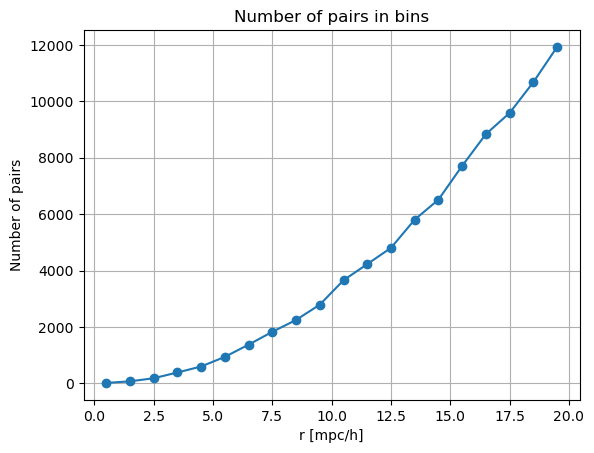

In [16]:
#noto che è un array che ha una serie di cose informazioni osdinate e soprattutto ha le coppie 
bin_centers= 0.5*(bin_edges[1:]+bin_edges[:-1])

#voglio tolgiere il primo elemento che è 0
RR['npairs'][0] -= n_points
#il primo elemento che è 0
#RR['npairs'] = np.delete(RR['npairs'], 0)

plt.plot(bin_centers, RR['npairs'], 'o-')
plt.xlabel('r [mpc/h]')
plt.ylabel('Number of pairs')
plt.title('Number of pairs in bins')
#plt.xscale('log')
#plt.yscale('log')
plt.grid()
plt.show()
#facccio il plot in fuznione della separazione

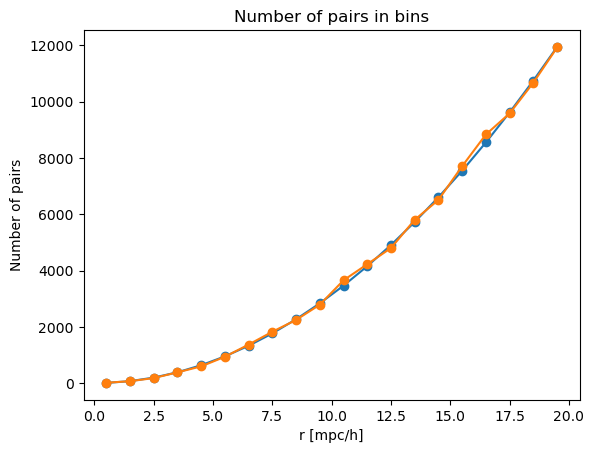

In [17]:
#il primissimo bin è il numero di oggetti più il numero di oppie infatti il primo bin picco è il segnale di correlazione più il segnale a separazione zero se partiva da unpò più lontano queel e coppie no c'erano
#numero medio di oggeti random attorno ad un ofggetot 
pairs_per_object = density * 4/3 * np.pi * (bin_edges[1:]**3 - bin_edges[:-1]**3)

plt.plot(bin_centers, n_points* pairs_per_object, 'o-')
plt.plot(bin_centers, RR['npairs'], 'o-')
plt.xlabel('r [mpc/h]')
plt.ylabel('Number of pairs')
plt.title('Number of pairs in bins')
plt.show()

In [14]:
#vedo che il numero di coppie è più grande del numero di oggetti quindi la correlazione è positiva si parlano 
#cosa succede se metto periodi false